In [27]:
from sklearn.datasets import fetch_california_housing
import numpy as np
import copy
import torch
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
torch.manual_seed(0)



m = nn.Dropout(p=0.2)
input = torch.randn(20, 1)
torch.cat((m(input), input),axis=1)


tensor([[-1.4073, -1.1258],
        [-1.4405, -1.1524],
        [-0.3132, -0.2506],
        [-0.5423, -0.4339],
        [ 0.7485,  0.5988],
        [-1.9439, -1.5551],
        [-0.4267, -0.3414],
        [ 2.3163,  1.8530],
        [ 0.5851,  0.4681],
        [-0.0000, -0.1577],
        [ 1.8046,  1.4437],
        [ 0.3326,  0.2660],
        [ 1.7367,  1.3894],
        [ 1.9829,  1.5863],
        [ 0.0000,  0.9463],
        [-1.0546, -0.8437],
        [ 1.1648,  0.9318],
        [ 1.5738,  1.2590],
        [ 2.5062,  2.0050],
        [ 0.0000,  0.0537]])

In [34]:
data = fetch_california_housing()
print(data.feature_names)
X, y = data.data, data.target

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [35]:
# train-test split of the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(dataset = train_dataset, batch_size = 3000, shuffle=True) 

In [36]:
# Define the model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(8, 24), # eight inputs
            nn.Dropout(0.5),
            nn.ReLU(),
            nn.Linear(24, 12),
            nn.Dropout(0.5),
            nn.ReLU(),
            nn.Linear(12, 6),
            nn.ReLU(),
            nn.Linear(6, 1) # one output
        )
    
    def forward(self, x):
        output = self.linear_relu_stack(x)
        return output

model = NeuralNetwork()
print(model)

# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.01)

NameError: name 'device' is not defined

In [31]:
# training parameters
n_epochs = 100   # number of epochs to run
batch_size = 10  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)
 
# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []
 
# training loop
for epoch in range(n_epochs):
    print(epoch)
    model.train() # tell pytorch you are training
    for X_batch, y_batch in train_loader:
        # forward pass
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        # backward pass
        optimizer.zero_grad()
        loss.backward()
        # update weights
        optimizer.step()

    # evaluate accuracy at end of each epoch
    model.eval() # tell pytorch you are testing
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)

    y_train_pred = model(X_train)
    train_err = loss_fn(y_train_pred, y_train)
    train_err = float(train_err)
    history.append([mse, train_err])
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())
 
# restore model and return best accuracy
model.load_state_dict(best_weights)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


<All keys matched successfully>

In [32]:
print("Model's state_dict:")
for param_tensor in model.state_dict():
    print(param_tensor, "\t", model.state_dict()[param_tensor])

Model's state_dict:
linear_relu_stack.0.weight 	 tensor([[ 1.8979e-01,  1.4198e-02,  6.6706e-02, -1.0828e-01, -2.4657e-01,
         -7.7374e-02, -4.5091e-01, -1.3454e-01],
        [ 2.8420e-01,  5.2015e-01,  5.2040e-01,  1.0418e-01,  6.7406e-02,
          3.5944e-01,  5.9385e-01, -1.0616e-01],
        [ 4.7763e-02,  2.3705e-01, -2.0817e-01,  6.5883e-02, -2.7411e-01,
         -2.4504e-01, -1.8264e-01,  1.5997e-01],
        [ 1.4219e-01, -2.0943e-01,  1.0681e-01,  1.9409e-01, -4.4625e-02,
          1.3499e-02,  8.1920e-02,  2.1934e-01],
        [ 2.4891e-01, -3.5794e-01, -2.1373e-01,  5.7955e-02,  1.8930e-01,
          2.1095e-01,  2.2745e-01,  1.5483e-01],
        [-4.2270e-01, -8.1113e-02, -3.3645e-01, -4.4480e-01,  1.9143e-01,
          1.4738e-01, -4.6806e-01,  1.8158e-01],
        [-5.9560e-02, -5.8181e-02, -1.6184e-01,  1.3596e-01, -2.0941e-01,
          1.2961e-01,  1.7879e-01,  2.5310e-01],
        [ 1.5727e-01, -3.1471e-01, -1.9623e-01,  2.1202e-01,  1.1329e-01,
         -2.5250

MSE: 1.17
RMSE: 1.08


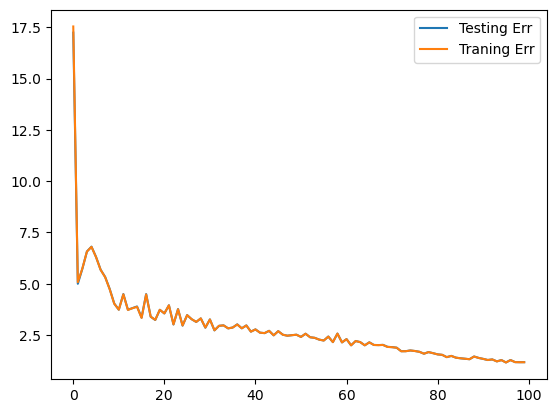

In [33]:
import matplotlib.pyplot as plt
print("MSE: %.2f" % best_mse)
print("RMSE: %.2f" % np.sqrt(best_mse))
plt.plot(history)
plt.legend(["Testing Err", "Traning Err"])
plt.show()